# Kuzishiji Handwriting Recognition
***Skills***_: Machine Learning, Python (Scikit-Learn, TensorFlow, Matplotlib, NumPy, Pandas)_

## Overview
Many historical manuscripts, letters, and books remain inaccessible to the general Japanese public as the ancient Kuzushiji script has fazed out of popularity. Furthermore, the same character can be written in multiple ways, leaving some texts intelligible to all but expert linguists. As such, I developed a machine learning pipeline for recognizing common Kuzishiji characters in handwriting and translating them into modern Japanese (Romaji). It performs a Bayesian grid search to optimize hyperparameters for each model, automatically selecting the most performative model. It also compares the performance of both pixel and embedding representations of the data. The following models have been implemented:

Classical Machine Learning:
- Logistic Regression
- Nearest Neighbour
- Decision Tree
- Random Forest
- Histogram Gradient Boosting

Deep Learning:
- Stochastic Gradient Descent
- Multilayer Perceptron
- Convolutional Neural Network

## Data Source
- **Kuzushiji-MNIST**: a dataset of 70.0000 handwritten images (28x28 grayscale) of the 10 most common Kanji characters in a variety of Kuzushiji handwritings, from [Kaggle](https://www.kaggle.com/datasets/anokas/kuzushiji).

## Data Processing
- **Conversion**: Scaling, labeling, and encoding have been implemented
- **Embedding**: 

## Setup
Import libraries, check versioning, set plot display, and hide convergence warnings.

In [101]:
# ==============================
# Setup
# ==============================

## Import libraries
import gdown
import math
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import openml
import optuna
from packaging import version
import pandas as pd
from IPython import display
import joblib
import statistics 
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_validate, ParameterGrid
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import shuffle
import time
import tensorflow as tf
from tensorflow.keras import layers, losses, metrics, models, optimizers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tqdm.auto import tqdm
import warnings

## Check sklearn version
sklearn_version = sklearn.__version__
if version.parse(sklearn_version) < version.parse("1.6.0"):
    print("scikit-learn is outdated (currently: {}, required: 1.6.0 or higher). Please update by running 'pip install -U scikit-learn' in your terminal".format(sklearn_version))
else:
    print("scikit-learn version is OK (currently: {})".format(sklearn_version))

## Display plots directly in notebook
%matplotlib inline

## Hide convergence warning
from sklearn.exceptions import ConvergenceWarning
from sklearn.utils._testing import ignore_warnings
warnings.simplefilter(action="ignore", category=ConvergenceWarning)

scikit-learn version is OK (currently: 1.6.1)


## Load & preprocess data
Load Kuzushiji-MNIST, split and scale data, and define labels and classes.

In [28]:
# ==============================
# Load & preprocess data
# ==============================

# Load Devanagari data from OpenML
data = openml.datasets.get_dataset("Kuzushiji-MNIST", download_data=True)
Kuzushiji_X, Kuzushiji_y, _, _ = data.get_data(target=data.default_target_attribute)

# Scaling to [0..1] as Logistic Regression can be sensitive to scale
Kuzushiji_X_scaled = Kuzushiji_X / 255.0

# Split the data, using 25% for training and 25% for testing (in the interest of time/resources)
X, X_eval, y, y_eval = train_test_split(Kuzushiji_X_scaled, Kuzushiji_y, stratify=Kuzushiji_y, train_size=0.25, test_size=0.25, random_state=0)

# Convert to numpy arrays for models that require it
X_np = X.to_numpy()
X_eval_np = X_eval.to_numpy()

# Encode labels as integers
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_eval_enc = le.transform(y_eval)

# Sorted label list
labels = sorted([label for label in set(Kuzushiji_y)])

# Map Kuzushiji characters
Kuzushiji_labels = ["o", "ki", "su", "tsu", "na", "ha", "ma", "ya", "re", "wo"]
Kuzushiji_classes = {0:"o", 1: "ki", 2: "su", 3: "tsu", 4: "na", 5: "ha", 6: "ma", 7: "ya", 8: "re", 9: "wo"}

# Function to get indices of examples of a given class
def y_class(c, num_ex):
    return y[y == c].index.values.tolist()[:num_ex]

## Data Exploration
As can be seen in the dataset, the same Kuzushiji characters can be written in many different ways.

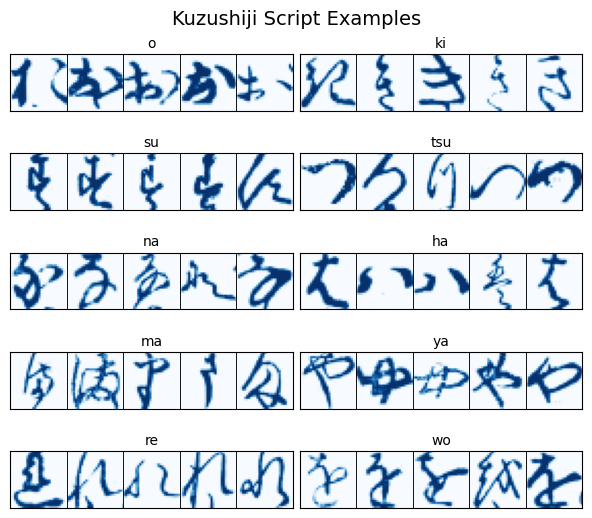

In [29]:
# ==============================
# Plot Kuzushiji characters
# ==============================

# Plot examples for each class
def plot_class_examples(images, labels, num_per_class=7, class_names=None, title=""):
    """
    Plot each class in its own subplot, arranging the subplots in 2 columns.
    Each example is a separate square image with its own border.
    """
    classes = sorted(labels.unique())
    n_classes = len(classes)
    n_cols = 2
    n_rows = math.ceil(n_classes / n_cols)
    row_len = num_per_class
    n_img_rows = math.ceil(num_per_class / row_len)

    # Create figure and axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(num_per_class + 1, n_rows + 1))
    axes = np.atleast_2d(axes).flatten()
    
    # Plot each class in its own subplot
    for i, c in enumerate(classes):
        ax = axes[i]
        idx = labels[labels == c].index[:num_per_class]
        class_images = images.loc[idx]
        
        ax.set_aspect('equal')
        ax.set_xlim(0, row_len*28)
        ax.set_ylim(0, n_img_rows*28)
        
        for j, (_, row) in enumerate(class_images.iterrows()):
            r = j // row_len
            c_ = j % row_len
            img = row.values.reshape(28,28)
            ax.imshow(img, cmap=plt.cm.Blues,
                      extent=(c_*28, (c_+1)*28, (n_img_rows-r-1)*28, (n_img_rows-r)*28))
            rect = patches.Rectangle((c_*28, (n_img_rows-r-1)*28), 28, 28,
                                     linewidth=0.5, edgecolor='black', facecolor='none')
            ax.add_patch(rect)
        
        ax.set_xticks([])
        ax.set_yticks([])
        if class_names:
            ax.set_title(class_names[int(labels[idx[0]])], fontsize=10, pad=5)
    
    # Turn off unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    # Add title
    if title:
        fig.suptitle(title, fontsize=14, y=0.9)
    
    # Plot & save figure
    plt.tight_layout(pad=1.0, h_pad=0.5, w_pad=0.5, rect=[0,0,1,0.95])
    plt.savefig("Kuzushiji Script.png", bbox_inches='tight')
    plt.show()

plot_class_examples(X, y, num_per_class=5, class_names=Kuzushiji_classes, title="Kuzushiji Script Examples")

## Embeddings
Given the high variability in the way characters are written, models can easily overfit on certain Pixel. As such, vector embeddings are preferred for robustness over the original pixel representation. A deep learning model (MobileNet, pretrained on ImageNet) is used to extract vector representations of the images, allowing the derived features to be used to train machine learning models.

In [136]:
# ==============================
# Create image embeddings
# ==============================

# Create image embeddings using MobileNetV2
def create_embedding(X, batch_size=32):
    X = X*255.0 # MobileNetV2 was likely trained on ImageNet data in the standard [0,255] scale
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    n_batches = int(np.ceil(X.shape[0] / batch_size))
    all_embeddings = []

    # Initialize MobileNetV2, only keep the embedding layers, use the smallest available input shape
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3), pooling='avg')

    # Process data in batches (to avoid memory issues)
    for i in tqdm(range(n_batches)):
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        X_batch = X[start_idx:end_idx]

        X_reshaped = X_batch.reshape((-1, 28, 28)) # Convert our pixel vectors to 28x28 images and add a channel dimension
        X_reshaped = np.stack((X_reshaped,)*3, axis=-1) # Convert to 3 channels (required for MobileNet) by duplicating the grayscale data
        X_resized = tf.image.resize(X_reshaped, [96,96]).numpy() # Upscale images to 96x96 to fit smallest supported MobileNetV2 resolution
        X_preprocessed = preprocess_input(X_resized) # Preprocess images according to MobileNetV2 requirements

        # Generate embeddings for the batch through the pretrained network
        batch_embeddings = base_model.predict(X_preprocessed, batch_size=batch_size, verbose=0)
        all_embeddings.append(batch_embeddings)

    # Concatenate all batch embeddings
    embeddings = np.vstack(all_embeddings)
    return embeddings

# Uncomment to generate and save embeddings (takes a while)
"""
X_embed_train = create_embedding(X, batch_size=32)
X_embed_test = create_embedding(X_eval, batch_size=32)
np.save("X_embed_train.npy", X_embed_train)
np.save("X_embed_test.npy", X_embed_test)
"""

# Load saved embedded data and convert to numpy arrays
X_embed = np.load("Data/X_embed_train.npy")
X_eval_embed = np.load("Data/X_embed_test.npy")

17500


## Dimensionality Visualisation
t-SNE was used to visualize the high-dimensional embeddings as a 2D scatterplot. As shown below, the classes form clear clusters, suggesting that the vector embeddings can be used to distinguish them.

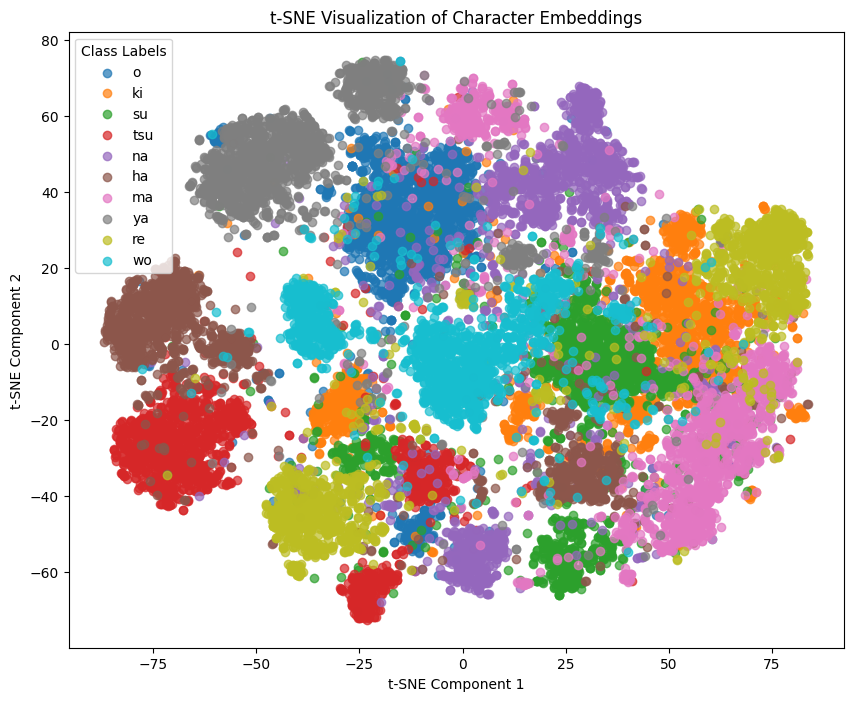

In [31]:
# ==============================
# Plot t-SNE visualization of embedding dimensions
# ==============================

def plot_tsne():
  # Perform t-SNE
  tsne = TSNE(n_components=2, perplexity=30, random_state=42)
  embeddings_2d = tsne.fit_transform(X_embed)

  # Plot the t-SNE embedding
  plt.figure(figsize=(10, 8))
  y_numeric = y.astype(int)
  unique_labels = np.unique(y_numeric)
  cmap = plt.get_cmap('tab10')
  for label in unique_labels:
      indices = y_numeric == label
      plt.scatter(
          embeddings_2d[indices, 0], embeddings_2d[indices, 1],
          color=cmap(label), label=Kuzushiji_classes[label], alpha=0.7
      )
  plt.xlabel("t-SNE Component 1")
  plt.ylabel("t-SNE Component 2")
  plt.title("t-SNE Visualization of Character Embeddings")
  plt.legend(title="Class Labels", loc="best")
  plt.show()

plot_tsne()

## Embedding-Pixel Representation Comparison

To optimize performance I implemented a logistic regression model evaluation and hyperparameter tuning pipeline. It uses L-BFGS and 5-fold stratified cross-validation on a 25% subsample of the Devanagari dataset across a log-scale range, then visualized train and test performance to identify near-optimal hyperparameters.

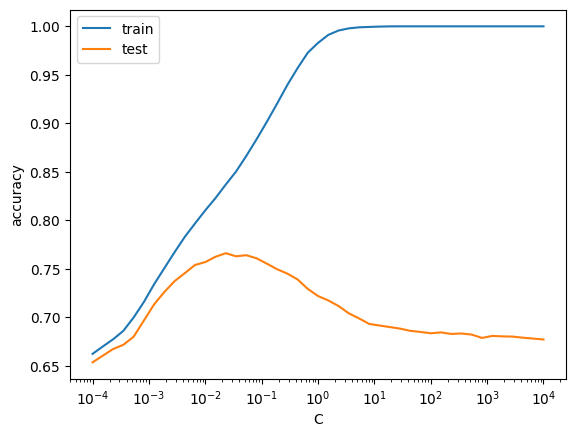

In [ ]:
# ==============================
# Plot Logistic Regression C-curve
# ==============================

def evaluate_LR(X, y, C):
    """ Evaluate a Logistic Regression model with cross-validation on the provided image data.
    Keyword arguments:
    X -- the data for training and testing
    y -- the correct output values
    C -- the regularization constant

    Returns: a dictionary with the mean train and test score, e.g. {"train": 0.9, "test": 0.95}
    """
    model = LogisticRegression(C=C, solver='lbfgs')
    cross_val = cross_validate(model, X, y, return_train_score=True, cv = 5, scoring = 'accuracy')
    train_mean = np.mean(cross_val["train_score"]);
    test_mean = np.mean(cross_val["test_score"]);
    return {"train": train_mean, "test": test_mean}

def plot_curve(X,y,train_size):
    """ Plots the train and test accuracy of logistic regression on a
    subsample of the given data for different amounts of regularization.
    X          -- the data for training and testing
    y          -- the correct labels
    train_size -- the proportion of the data used for training and testing, between 0.0 and 1.0.

    Returns: a plot as described above, with C on the x-axis and accuracy on
    the y-axis.
    """
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = 1 - train_size, stratify=y, random_state=0)
    C = np.logspace(-4, 4, 45);
    evaluations = [];
    for c in C:
        evaluations.append(evaluate_LR(X_train, y_train, c))
    df = pd.DataFrame(evaluations)
    
    line_train, = plt.plot(C, df["train"], label="train")
    line_test, = plt.plot(C, df["test"], label="test")
    plt.legend(handles=[line_train, line_test])
    plt.xlabel("C")
    plt.ylabel("accuracy")
    plt.xscale("log")
    plt.show()

plot_curve(X,y,0.25)

## Embedding-Pixel Representation Comparison
As shown above, test accuract peaks at C = 0.3 (3*10^-1) before overfitting, leaving it the optimal value for model evaluation. As shown, the deep learning embedding representation works much better since it represents general components of images (e.g. lines and curves) compared to the more trivial pixel data.

In [ ]:
def evaluate_test(X_train, y_train, X_eval, y_eval):
    """ Evaluate a Logistic Regression model
    X_train -- the training data
    y_train -- the training labels
    X_eval  -- the evaluation (test) data
    y_eval  -- the evaluation (test) labels

    Returns: the evaluation score (accuracy) of the optimal model trained on pixel data
    """
    C=0.3
    model = LogisticRegression(C=C)
    fit = model.fit(X_train, y_train)
    y_pred = fit.predict(X_eval)
    score = sklearn.metrics.accuracy_score(y_eval, y_pred)
    return score

pixel_score = evaluate_test(X, y, X_eval, y_eval)
embedding_score = evaluate_test(X_embed, y, X_eval_embed, y_eval)
print(f"Pixel representation accuracy: {pixel_score * 100:.3f}%")
print(f"Embedding representation accuracy: {embedding_score * 100:.3f}%")


Pixel representation accuracy: 78.514%
Embedding representation accuracy: 90.909%


# Few-shot Learning
Performance was also evaluated for a smaller dataset (1% of the data) to test robustness of the embedded representation. As shown, embedding model performance is significantly reduced but still outperforms the pixel model, suggesting that the embedding representation can be used to learn robust patterns.

In [ ]:
def evaluate_few_shot(X_train, y_train, X_eval, y_eval):
    """ Evaluate a Logistic Regression model
    X_train -- the training data
    y_train -- the training labels
    X_eval  -- the evaluation (test) data
    y_eval  -- the evaluation (test) labels

    Returns: the evaluation score (accuracy) of the optimal model trained on pixel data
    """
    C=0.3
    X_train_few, _, y_train_few, _ = train_test_split(X_train, y_train, train_size = 0.01, stratify = y_train, random_state=0)
    
    model = LogisticRegression(C=C)
    fit = model.fit(X_train_few, y_train_few)
    y_pred = fit.predict(X_eval)
    score = sklearn.metrics.accuracy_score(y_eval, y_pred)
    return score

pixel_score = evaluate_few_shot(X, y, X_eval, y_eval)
embedding_score = evaluate_few_shot(X_embed, y, X_eval_embed, y_eval)
print(f"Pixel representation accuracy: {pixel_score * 100:.3f}%")
print(f"Embedding representation accuracy: {embedding_score * 100:.3f}%")

Pixel representation accuracy: 62.526%
Embedding representation accuracy: 68.994%


# Model Inspection
Visualizes heat maps of the embedded logistic regression model at different values of C (C = 1e-4, C = 1e-1, C = 1e4) to evaluate for overfitting and underfitting. Stochastic Average Gradient Descent is used with 100 train-test splits (75-25).

C = 1e-04
Mean-median ratio: 0.005
Low-impact pixels (<1% weight of max weight): 5.102%
C = 1e-01
Mean-median ratio: 0.474
Low-impact pixels (<1% weight of max weight): 2.423%
C = 1e+04
Mean-median ratio: -0.834
Low-impact pixels (<1% weight of max weight): 2.296%


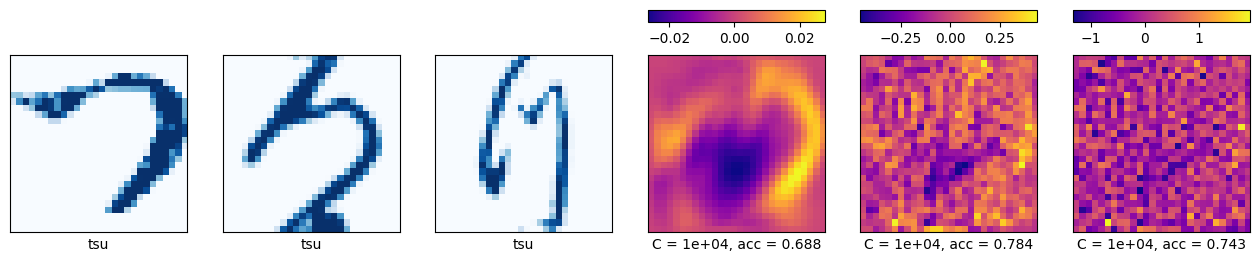

In [41]:
def plot_character_coefficients(X, y, character, penalty, max_iter):
    """ Plots 28x28 heatmaps showing the coefficients of three Logistic
    Regression models, each with different amounts of regularization values.
    X -- the data for training and testing
    y -- the correct labels
    character -- the character to plot
    penalty -- the penalty to use, e.g. 'l2'

    Returns: 4 plots, as described above.
    """
    C = [1e-4, 1e-1, 1e4]
    examples = 3

    key = str([key for key, val in Kuzushiji_classes.items() if val == character][0])
    class_indices = y[y == key].index
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, stratify=y, random_state=0)

    fig, axes = plt.subplots(1,len(C)+examples,figsize=(16,4))
    for i, ax in enumerate(axes):
        if(i < examples):
            image = X.loc[class_indices[i]]
            ax.imshow(image.values.reshape(28, 28), cmap=plt.cm.Blues)
            ax.set_xlabel(character)
            ax.set_xticks(()), ax.set_yticks(())
        else:
            model = LogisticRegression(solver='saga', max_iter=max_iter, penalty=penalty, C=C[i-examples], random_state=0)
            fit = model.fit(X_train, y_train)
            y_pred = fit.predict(X_test)
            score = accuracy_score(y_test, y_pred)
            heatmap = ax.imshow(model.coef_[int(key)].reshape(28,28), cmap='plasma')
            ax.set_xlabel("C = {:.0e}, acc = {:.3f}".format(C[examples-1], score))
            ax.set_xticks(()), ax.set_yticks(())
            ax_left = ax.get_position().x0
            ax_width = ax.get_position().width
            cax = fig.add_axes([ax_left, 0.8, ax_width, 0.03])
            fig.colorbar(heatmap, cax=cax, orientation='horizontal')
            print("C = " f"{C[i-examples]:.0e}")
            
            # Time per model
            # %timeit fit = model.fit(X_train, y_train) # Uncomment to time models

            # Mean-median ratio
            values = model.coef_[int(key)].reshape(28,28)
            values = [value for val in values for value in val]
            mean = statistics.mean(values)
            median = statistics.median(values)
            print("Mean-median ratio: " f"{mean/median:.3f}")

            # Fraction of low-impact pixels
            values_abs = [abs(value) for value in values]
            cutoff = 0.01 * max(values_abs)
            low_impact_pixels = sum(j < cutoff for j in values_abs) / (28*28)
            print("Low-impact pixels (<1% weight of max weight): " f"{low_impact_pixels * 100:.3f}%")
    plt.show()

plot_character_coefficients(X, y, 'tsu', 'l2', 200)

## Incremental Learning
To verify that embeddings still outperform pixel representations for incremental learning models, an SGD-based Logistic Regression model is incrimentally trained over multiple epochs and batches (optimal alpha value is determined beforehand based on 10 epochs). The data is split once (80-20 stratified), reshuffled each epoch, and trained using partial fit for continuous learning.

As shown, embedded data once again outperforms pixel data slightly (59.9% vs 55.2%). Its learning curve also converges slightly faster, suggesting it can be used for faster model training.


 Best alpha: 1.3e-01 (average validation accuracy = 54.105%)


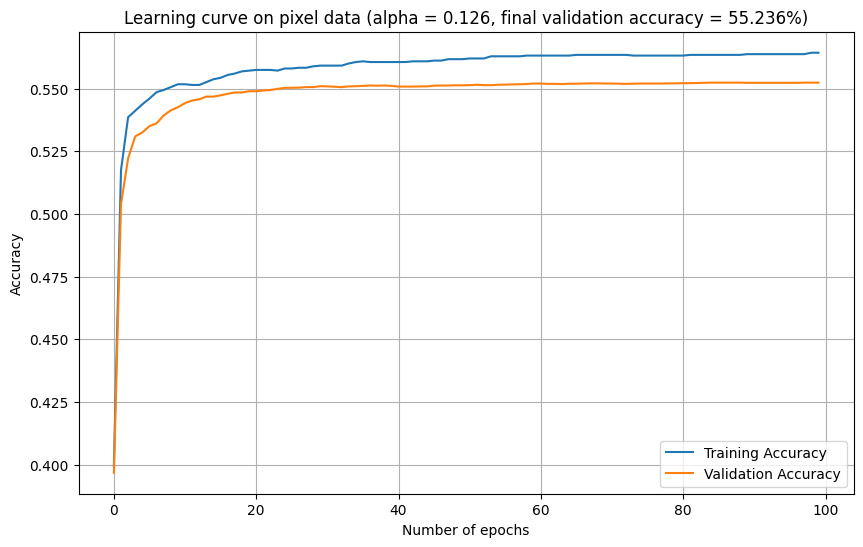

Learning curve converged at epoch 16 (at 99% of final validation accuracy)

 Best alpha: 6.3e-02 (average validation accuracy = 58.279%)


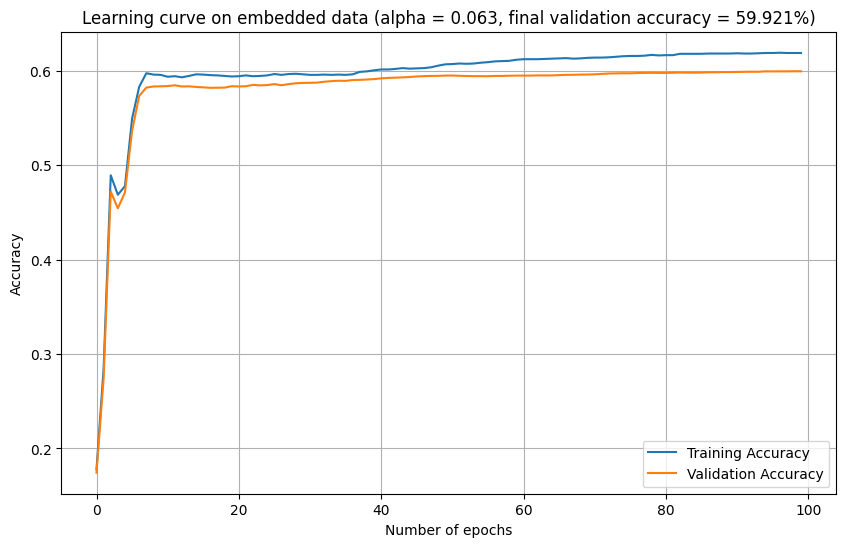

Learning curve converged at epoch 46 (at 99% of final validation accuracy)


In [ ]:
def find_best_alpha(X, y, alphas=None, n_epochs=10, batch_size=100):
    """ Test several alpha values and select the one with the highest average validation accuracy. """
    if alphas is None:
        alphas = np.logspace(-6, 0, 21)  # [1e-6, 1e-5, ..., 1]

    best_alpha = None
    best_val_acc = -np.inf
    results = []

    for alpha in alphas:
        train_scores, val_scores, _, _ = learning_curve(X, y, alpha=alpha, n_epochs=n_epochs, batch_size=batch_size)
        mean_val_acc = np.mean(val_scores[-3:])  # smooth end values
        results.append((alpha, mean_val_acc))
        if mean_val_acc > best_val_acc:
            best_val_acc = mean_val_acc
            best_alpha = alpha

    print(f"\n Best alpha: {best_alpha:.1e} (average validation accuracy = {best_val_acc * 100:.3f}%)")
    return best_alpha

def learning_curve(X, y, alpha=None, n_epochs=1, batch_size=100):
    """ Trains a Logistic Regression model incrementally using stochastic gradient descent and returns the learning curves. """
    if alpha is None:
        alpha = find_best_alpha(X, y)
    model = SGDClassifier(alpha=alpha, max_iter=1, random_state=0, learning_rate='optimal', loss='log_loss')
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8, stratify=y, random_state=0)
    classes = np.unique(y)
    train_scores, val_scores = [], []

    for _ in range(n_epochs):
        X_batch, y_batch = shuffle(X_train, y_train, n_samples=batch_size, random_state=0)
        model.partial_fit(X_batch, y_batch, classes=classes)
        train_scores.append(accuracy_score(y_train, model.predict(X_train)))
        val_scores.append(accuracy_score(y_val, model.predict(X_val)))
    
    return train_scores, val_scores, n_epochs, alpha


def plot_learning_curves(train_accuracies, val_accuracies, n_epochs, alpha, title='Learning Curve Across Epochs'):
    plt.figure(figsize=(10, 6))
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Number of epochs')
    plt.ylabel('Accuracy')
    plt.title(f"Learning curve on {title} (alpha = {alpha:.3f}, final validation accuracy = {100 * val_accuracies[-1]:.3f}%)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Find convergence epoch
    convergence_epoch = next((i+1 for i, acc in enumerate(val_accuracies) if acc >= 0.99 * val_accuracies[-1]), None)
    if convergence_epoch:
        print(f"Learning curve converged at epoch {convergence_epoch} (at 99% of final validation accuracy)")

plot_learning_curves(*learning_curve(X, y, n_epochs=100), title="pixel data")
plot_learning_curves(*learning_curve(X_embed, y, n_epochs=100), title="embedded data")

Params: {'batch_size': 128, 'l2_reg': 0.0, 'learning_rate': 0.01, 'n_epochs': 5} -> Validation Accuracy: 0.550
Params: {'batch_size': 128, 'l2_reg': 0.0, 'learning_rate': 0.001, 'n_epochs': 5} -> Validation Accuracy: 0.200
Params: {'batch_size': 128, 'l2_reg': 0.0001, 'learning_rate': 0.01, 'n_epochs': 5} -> Validation Accuracy: 0.600
Params: {'batch_size': 128, 'l2_reg': 0.0001, 'learning_rate': 0.001, 'n_epochs': 5} -> Validation Accuracy: 0.200
Params: {'batch_size': 256, 'l2_reg': 0.0, 'learning_rate': 0.01, 'n_epochs': 5} -> Validation Accuracy: 0.550
Params: {'batch_size': 256, 'l2_reg': 0.0, 'learning_rate': 0.001, 'n_epochs': 5} -> Validation Accuracy: 0.350
Params: {'batch_size': 256, 'l2_reg': 0.0001, 'learning_rate': 0.01, 'n_epochs': 5} -> Validation Accuracy: 0.550
Params: {'batch_size': 256, 'l2_reg': 0.0001, 'learning_rate': 0.001, 'n_epochs': 5} -> Validation Accuracy: 0.200

Best parameters: {'batch_size': 128, 'l2_reg': 0.0001, 'learning_rate': 0.01, 'n_epochs': 5}, B

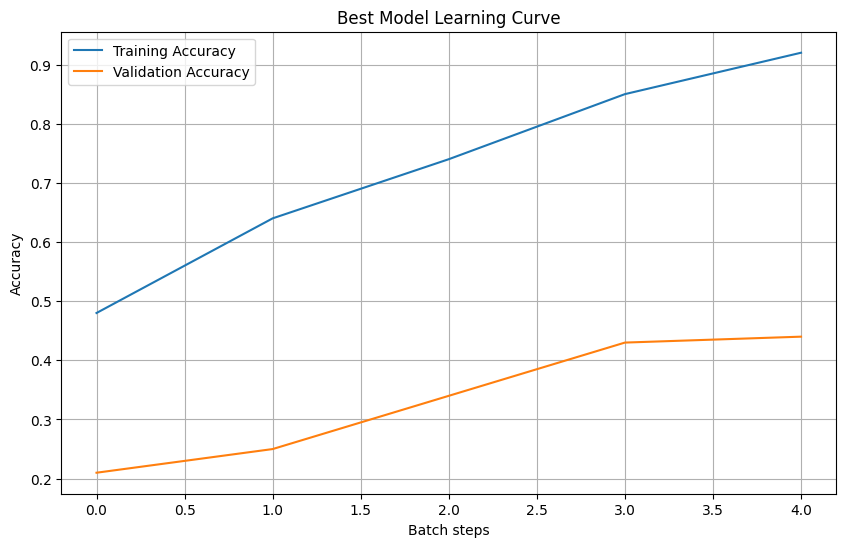

In [42]:
# ==============================
# Data preparation
# ==============================
def prepare_data(X, y, val_size=0.2, random_state=0):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=val_size, stratify=y, random_state=random_state
    )
    return X_train, X_val, y_train, y_val

# ==============================
# Model definition
# ==============================
def create_logistic_model(input_shape, n_classes, learning_rate=0.01, l2_reg=0.0):
    model = models.Sequential([
        layers.InputLayer(shape=input_shape),
        layers.Dense(
            n_classes,
            activation='softmax',
            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
        )
    ])
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=[metrics.SparseCategoricalAccuracy()]
    )
    return model

# ==============================
# Learning curve trainer
# ==============================
def train_with_learning_curve(model, X_train, y_train, X_val, y_val, batch_size=128, n_epochs=5):
    train_acc = []
    val_acc = []

    n_batches = int(np.ceil(len(X_train) / batch_size))

    for epoch in range(n_epochs):
        # Shuffle dataset each epoch
        idx = np.random.permutation(len(X_train))
        X_train, y_train = X_train[idx], y_train[idx]

        for i in range(n_batches):
            start = i * batch_size
            end = min(start + batch_size, len(X_train))
            X_batch, y_batch = X_train[start:end], y_train[start:end]
            model.train_on_batch(X_batch, y_batch)

            # Evaluate after each batch
            train_metrics = model.evaluate(X_train, y_train, verbose=0)
            val_metrics = model.evaluate(X_val, y_val, verbose=0)
            train_acc.append(train_metrics[1])
            val_acc.append(val_metrics[1])

    return train_acc, val_acc

# ==============================
# Plot learning curves
# ==============================
def plot_learning_curves(train_acc, val_acc, title="Learning Curve"):
    plt.figure(figsize=(10,6))
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.xlabel('Batch steps')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# ==============================
# Hyperparameter search
# ==============================
def grid_search(X, y, param_grid):
    best_params = None
    best_val_acc = -np.inf

    for params in ParameterGrid(param_grid):
        X_train, X_val, y_train, y_val = prepare_data(X, y, val_size=0.2)
        model = create_logistic_model(
            input_shape=X.shape[1:],
            n_classes=len(np.unique(y)),
            learning_rate=params['learning_rate'],
            l2_reg=params['l2_reg']
        )
        train_acc, val_acc = train_with_learning_curve(
            model,
            X_train, y_train,
            X_val, y_val,
            batch_size=params['batch_size'],
            n_epochs=params['n_epochs']
        )
        final_val_acc = val_acc[-1]
        print(f"Params: {params} -> Validation Accuracy: {final_val_acc:.3f}")

        if final_val_acc > best_val_acc:
            best_val_acc = final_val_acc
            best_params = params

    print(f"\nBest parameters: {best_params}, Best validation accuracy: {best_val_acc:.3f}")
    return best_params

# ==============================
# Example usage
# ==============================
param_grid = {
    'learning_rate': [0.01, 0.001],
    'l2_reg': [0.0, 1e-4],
    'batch_size': [128, 256],
    'n_epochs': [5]
}

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Assuming X, y are your dataset (numpy arrays)
best_params = grid_search(X[:100].to_numpy(), y_encoded[:100], param_grid)

best_model = create_logistic_model(
    input_shape=X.shape[1:],
    n_classes=len(np.unique(y)),
    learning_rate=best_params['learning_rate'],
    l2_reg=best_params['l2_reg']
)

train_acc, val_acc = train_with_learning_curve(
    best_model, X[:100].to_numpy(), le.fit_transform(y[:100]), X_eval[:100].to_numpy(), le.fit_transform(y_eval[:100]),
    batch_size=best_params['batch_size'], n_epochs=best_params['n_epochs']
)
plot_learning_curves(train_acc, val_acc, title="Best Model Learning Curve")


In [43]:
# ==============================
# TensorFlow model wrappers
# ==============================
class SGDModel:
    def __init__(self, input_shape, n_classes, learning_rate=0.01, l2_reg=0.0):
        self.model = models.Sequential([
            layers.InputLayer(shape=input_shape),
            layers.Dense(n_classes, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))
        ])
        self.model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=[metrics.SparseCategoricalAccuracy()]
        )
        self.last_history = None

    def fit(self, train_ds, val_ds, n_epochs=5, verbose=0):
        history = self.model.fit(train_ds, validation_data=val_ds, epochs=n_epochs, verbose=verbose)
        self.last_history = history
        return history

class MLPModel(SGDModel):
    def __init__(self, input_shape, n_classes, learning_rate=0.01, l2_reg=0.0):
        self.model = models.Sequential([
            layers.InputLayer(shape=input_shape),
            layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg)),
            layers.Dense(n_classes, activation='softmax')
        ])
        self.model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=[metrics.SparseCategoricalAccuracy()]
        )
        self.last_history = None

class CNNModel(SGDModel):
    def __init__(self, input_shape, n_classes, learning_rate=0.01, l2_reg=0.0):
        self.model = models.Sequential([
            layers.InputLayer(shape=input_shape),
            layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
            layers.MaxPooling2D(pool_size=(2,2)),
            layers.Flatten(),
            layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg)),
            layers.Dense(n_classes, activation='softmax')
        ])
        self.model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=[metrics.SparseCategoricalAccuracy()]
        )
        self.last_history = None

In [44]:
# ==============================
# Model and hyperparameter configurations
# ==============================
model_classes = {
    'Logistic Regression':          LogisticRegression,
    'Nearest Neighbors':            KNeighborsClassifier,
    'Decision Tree':                DecisionTreeClassifier,
    'Random Forest':                RandomForestClassifier,
    'Histogram Gradient Boosting':  HistGradientBoostingClassifier,
    'Stochastic Gradient Descent':  SGDModel,
    'Multilevel Perceptron':        MLPModel,
    'Convolutional Neural Network': CNNModel
}

param_grid = {
    'C':                 np.logspace(-5, 5, 11),
    'n_neighbors':       list(range(1, 20)),
    'n_estimators':      list(range(10, 201, 10)),
    'max_depth':         list(range(1, 20)) + [None],
    'learning_rate':     np.logspace(-5, -1, 5),
    'l2_reg':            np.logspace(-5, 0, 6),
    'l2_regularization': np.logspace(-5, 0, 6),
    'n_epochs':          [5, 10, 20],
    'batch_size':        list(range(32, 256, 32))
}

model_param_map = {
    'Logistic Regression':          ['C'],
    'Nearest Neighbors':            ['n_neighbors'],
    'Decision Tree':                ['max_depth'],
    'Random Forest':                ['max_depth','n_estimators'],
    'Histogram Gradient Boosting':  ['max_depth','learning_rate','l2_regularization'],
    'Stochastic Gradient Descent':  ['learning_rate','l2_reg', 'n_epochs', 'batch_size'],
    'Multilevel Perceptron':        ['learning_rate','l2_reg','n_epochs', 'batch_size'],
    'Convolutional Neural Network': ['learning_rate','l2_reg','n_epochs', 'batch_size']
}

In [45]:
# ==============================
# Data handler
# ==============================
class DataHandler:
    def __init__(self, X, y, val_size=0.2, random_state=0):
        self.X = X
        self.y = y
        self.val_size = val_size
        self.random_state = random_state

    def get_tf_datasets(self, batch_size=128, model_type='Stochastic Gradient Descent'):
        X_train, X_val, y_train, y_val = train_test_split(
            self.X, self.y, test_size=self.val_size, stratify=self.y, random_state=self.random_state
        )
        if model_type == 'Convolutional Neural Network':
            X_train = X_train.reshape(-1, 28, 28, 1)
            X_val = X_val.reshape(-1, 28, 28, 1)
        train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
        val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
        return train_ds, val_ds

In [130]:
# ==============================
# Learning curve plotter
# ==============================
class LearningCurvePlotter:
    @staticmethod
    def plot(history, title="Learning Curve"):
        if history is None:
            print("No history to plot.")
            return
        plt.figure(figsize=(10,6))
        # handle both keras History and a direct history dict
        h = history.history if hasattr(history, 'history') else history
        if 'sparse_categorical_accuracy' in h:
            plt.plot(h['sparse_categorical_accuracy'], label='Training Accuracy')
        if 'val_sparse_categorical_accuracy' in h:
            plt.plot(h['val_sparse_categorical_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.show()

In [143]:
# ==============================
# Bayesian grid search
# ==============================
class BayesianGridSearch:
    def __init__(self, X, y, model_classes, model_param_map, param_grid,
                 n_trials=30, val_size=0.2, random_state=0,
                 X_eval=None, y_eval=None):
        """
        X, y: training arrays (np arrays)
        model_classes: dict model_name -> class
        model_param_map: dict model_name -> list of relevant hyperparameter names
        param_grid: dict hyperparameter -> list of candidate values (used for categorical sampling)
        """
        self.X = X
        self.y = y
        self.X_eval = X_eval
        self.y_eval = y_eval
        self.model_classes = model_classes
        self.model_param_map = model_param_map
        self.param_grid = param_grid
        self.n_trials = n_trials
        self.val_size = val_size
        self.random_state = random_state
        self.best_models_per_type = {}
        self.best_params_per_type = {}
        self.best_val_acc_per_type = {}

        # tracking
        self.best_params = None
        self.best_val_acc = -np.inf
        self.best_model_obj = None
        self.last_history_per_model = {}  # store last TF history per model type

        # label encoder
        self.encoder = LabelEncoder()
        self.y_encoded = self.encoder.fit_transform(self.y)
        if self.y_eval is not None:
            # transform eval labels with same encoder (if labels align)
            try:
                self.y_eval_encoded = self.encoder.transform(self.y_eval)
            except Exception:
                # if eval uses different labels, refit on combined
                le2 = LabelEncoder()
                le2.fit(np.concatenate([self.y, self.y_eval]))
                self.y_encoded = le2.transform(self.y)
                self.y_eval_encoded = le2.transform(self.y_eval)
                self.encoder = le2

    def _model_library(self, model_type):
        """Return the library ('tensorflow' or 'sklearn') used by the model."""
        if model_type in self.model_classes:
            if model_type in ['Stochastic Gradient Descent', 'Multilevel Perceptron', 'Convolutional Neural Network']:
                return 'tensorflow'
            else:
                return 'sklearn'

    def _sample_params_for_model(self, trial, model_type):
        """Sample only hyperparameters listed in model_param_map[model_type] using categorical choices from param_grid."""
        params = {'model_type': model_type}
        for hp in self.model_param_map[model_type]:
            if hp not in self.param_grid:
                continue
            choices = self.param_grid[hp]
            # if choices is a numpy array, convert to list (Optuna accepts list)
            if isinstance(choices, np.ndarray):
                choices = choices.tolist()
            # use categorical sampling over the provided grid
            params[hp] = trial.suggest_categorical(hp, choices)
        return params

    def _train_model(self, model_type, params):
        model_class = self.model_classes[model_type]
        y_enc = self.y_encoded

        # TensorFlow models: need datasets and separation of init vs fit args
        if self._model_library(model_type) == 'tensorflow':
            data = DataHandler(self.X, y_enc, val_size=self.val_size, random_state=self.random_state)
            train_ds, val_ds = data.get_tf_datasets(batch_size=params.get('batch_size', 128),
                                                    model_type=model_type)
            if model_type == 'Convolutional Neural Network':
                input_shape = (28, 28, 1)
            else:
                input_shape = (self.X.shape[1],)

            tf_kwargs = {'input_shape': input_shape, 'n_classes': len(np.unique(y_enc))}
            for hp in self.model_param_map[model_type]:
                if (
                    hp in params
                    and params[hp] is not None
                    and hp != 'batch_size'
                    and hp != 'n_epochs'
                ):
                    tf_kwargs[hp] = params[hp]

            print(tf_kwargs)
            model_obj = model_class(**tf_kwargs)
            n_epochs = int(params.get('n_epochs', 5))
            try:
                if model_type != 'Convolutional Neural Network':
                    # Only flatten if input is not already 2D
                    if len(input_shape) > 1 and input_shape[0] != 1280:
                        def flatten_ds(ds):
                            return ds.map(lambda x, y: (tf.reshape(x, (-1,)), y))
                        train_ds_flat = flatten_ds(train_ds)
                        val_ds_flat = flatten_ds(val_ds)
                    else:
                        train_ds_flat = train_ds
                        val_ds_flat = val_ds
                    history = model_obj.fit(train_ds_flat, val_ds_flat, n_epochs=n_epochs, verbose=0)
                else:
                    history = model_obj.fit(train_ds, val_ds, n_epochs=n_epochs, verbose=0)
                val_acc = float(history.history.get('val_sparse_categorical_accuracy', [0.0])[-1])
                self.last_history_per_model[model_type] = history
                return val_acc, model_obj, history
            except Exception as e:
                print(f"Error training {model_type}: {e}")
                return None
        else:
            # sklearn models
            try:
                # Prepare params for sklearn
                sk_params = {k: v for k, v in params.items() if k != 'model_type'}
                model_obj = model_class(**sk_params)
                X_train, X_val, y_train, y_val = train_test_split(
                    self.X, y_enc, test_size=self.val_size, stratify=y_enc, random_state=self.random_state
                )
                model_obj.fit(X_train, y_train)
                y_pred = model_obj.predict(X_val)
                val_acc = accuracy_score(y_val, y_pred)
                return val_acc, model_obj, None
            except Exception as e:
                print(f"Error training {model_type}: {e}")
                return None

    def run(self):
        """Run Optuna studies per model_type, save best models, evaluate on X_eval/y_eval,
        and return the overall best model based on evaluation accuracy."""
        val_split = int(100 * self.val_size)
        train_split = int(100 - val_split)
        print(f"Running {self.n_trials} trials per model type with {train_split}-{val_split} train-validation split")

        # Ensure dictionaries to store per-model-type results
        self.best_models_per_type = {}
        self.best_val_acc_per_type = {}
        self.best_eval_acc = -np.inf
        self.best_model_obj = None
        self.best_params = None

        for model_type in self.model_classes.keys():
            print(f"\n=== Optimizing {model_type} ===")
            study = optuna.create_study(direction='maximize', study_name=f"BayesSearch_{model_type}")

            def objective(trial, model_type=model_type):
                params = self._sample_params_for_model(trial, model_type)
                result = self._train_model(model_type, params)
                # Handle errors by skipping this trial
                if result is None:
                    raise optuna.TrialPruned()
                val_acc, model_obj, history = result

                # Track best model and params for this model type
                if model_type not in self.best_val_acc_per_type or val_acc > self.best_val_acc_per_type[model_type]:
                    self.best_val_acc_per_type[model_type] = val_acc
                    self.best_models_per_type[model_type] = model_obj
                    self.best_params_per_type[model_type] = params
                return val_acc

            study.optimize(objective, n_trials=self.n_trials)
            if model_type not in self.best_models_per_type:
                print(f"No successful trials for {model_type}, skipping.")
                continue
            best_model_obj = self.best_models_per_type[model_type]

            # -------------------------------
            # Save the best model for this type
            # -------------------------------
            if hasattr(best_model_obj, "model"):  # TensorFlow
                best_model_obj.model.save(f"Models/best_{model_type}_tf_model.keras")
            else:  # scikit-learn
                joblib.dump(best_model_obj, f"Models/best_{model_type}.pkl")

            # -------------------------------
            # Evaluate on evaluation set
            # -------------------------------
            if self.X_eval is not None and self.y_eval is not None:
                if hasattr(best_model_obj, "model"):  # TensorFlow
                    eval_data = DataHandler(self.X_eval, self.y_eval)
                    eval_ds, _ = eval_data.get_tf_datasets(batch_size=128, model_type=model_type)
                    eval_acc = best_model_obj.model.evaluate(eval_ds, verbose=0)[1]  # sparse_categorical_accuracy
                else:  # sklearn
                    eval_acc = accuracy_score(self.y_eval, best_model_obj.predict(self.X_eval))

                # Update global best based on evaluation accuracy
                if eval_acc > self.best_eval_acc:
                    self.best_eval_acc = eval_acc
                    self.best_model_obj = best_model_obj
                    self.best_params = study.best_params

            print(f"Best parameter values: {study.best_params}")
            print(f"Best validation accuracy = {100 * study.best_value:.3f}%")
            print(f"Evaluation accuracy = {100*eval_acc:.3f}%")

        print(f"\nOverall best model type: {type(self.best_model_obj).__name__}")
        print(f"Best params: {self.best_params}")
        print(f"Best evaluation accuracy: {100 * self.best_eval_acc:.3f}%")

        return self.best_model_obj, self.best_params, self.best_eval_acc

    def get_best_model(self):
        return self.best_model_obj

    def plot_predictions(self, X_eval, y_eval, class_names=None):
        """Plot confusion matrices and per-class accuracy for each best model per type."""
        if not hasattr(self, 'best_models_per_type') or len(self.best_models_per_type) == 0:
            print("No best models per type available.")
            return

        # Ensure numeric y_true
        y_true = y_eval
        if hasattr(self, 'encoder'):
            try:
                y_true = self.encoder.transform(y_eval)
            except Exception:
                pass

        for model_type, model in self.best_models_per_type.items():
            # Get predictions
            if hasattr(model, 'model'):  # TensorFlow models
                if isinstance(model.model.input_shape, tuple) and len(model.model.input_shape) == 4:
                    X_input = X_eval.reshape(-1, 28, 28, 1)
                else:
                    X_input = X_eval
                y_pred_probs = model.model.predict(X_input)
                y_pred = np.argmax(y_pred_probs, axis=1)
            else:  # sklearn models
                y_pred = model.predict(X_eval)

            # Confusion matrix
            cm = confusion_matrix(y_true, y_pred)
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-wise normalization

            # Remove 'model_type' from hyperparams for display
            hyperparams = self.best_params_per_type.get(model_type, {}).copy()
            hyperparams.pop('model_type', None)
            # Convert to (key1=val1, key2=val2) format, no quotes
            if hyperparams:
                hyperparam_str = "(" + ", ".join(f"{k}={v}" for k, v in hyperparams.items()) + ")"
            else:
                hyperparam_str = "()"

            # Plot confusion matrix with percentage formatting
            fig, ax = plt.subplots(figsize=(8, 8))
            cax = ax.matshow(cm_normalized, cmap=plt.cm.Blues)
            cb = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
            cb.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

            ax.set_xticks(range(len(class_names) if class_names else cm.shape[0]))
            ax.set_xticklabels(class_names if class_names else range(len(cm)))
            ax.set_yticks(range(len(class_names) if class_names else cm.shape[0]))
            ax.set_yticklabels(class_names if class_names else range(len(cm)))
            ax.set_ylim(cm.shape[0] - 0.5, -0.5)

            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    percent = cm_normalized[i, j] * 100
                    ax.text(j, i, f"{percent:.1f}%" if cm[i, j] > 0 else "",
                            ha='center', va='center',
                            color='white' if cm_normalized[i, j] > 0.5 else 'black')

            # Determine prefix for plot titles
            if self.X.shape[1] == 1280:  # MobileNetV2 embedding size
                prefix = " Embedded"
            else:
                prefix = " Pixel"

            ax.set_title(f"{prefix} {model_type} Confusion Matrix\nHyperparams: {hyperparam_str}", pad=20)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            plt.show()

            # Per-class accuracy bar plot with "Total" bar
            per_class_acc = cm.diagonal() / cm.sum(axis=1)
            overall_acc = accuracy_score(y_true, y_pred)
            bar_labels = ["Overall"] + (class_names if class_names else [str(i) for i in range(len(per_class_acc))])
            bar_values = [100 * overall_acc] + [100 * x for x in per_class_acc]

            plt.figure(figsize=(10, 4))
            bars = plt.bar(range(len(bar_values)), bar_values, color=[plt.cm.Blues(0.9)] + [plt.cm.Blues(0.7)]*len(per_class_acc))
            plt.ylim(0, 110)
            plt.xticks(range(len(bar_values)), bar_labels)
            plt.ylabel("Accuracy (%)")
            plt.title(f"{prefix} {model_type} Class Accuracy\nHyperparams: {hyperparam_str}")
            plt.ylim(0, 110)  # Add 10% headroom for text above bars
            plt.grid(axis='y', color=plt.cm.Blues(0.9), linestyle='-', linewidth=0.7, zorder=0, alpha=0.1)  # 10% opacity

            # Remove top and right spines
            ax = plt.gca()
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            for i, v in enumerate(bar_values):
                plt.text(i, v + 2, f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold' if i == 0 else 'normal')
            plt.show()

    def plot_histories(self):
        """Plot stored histories for TF models (if any)."""
        for model_type, history in self.last_history_per_model.items():
            if history is not None:
                LearningCurvePlotter.plot(history, title=f"{model_type} Learning Curve")

[I 2025-10-09 17:20:32,414] A new study created in memory with name: BayesSearch_Logistic Regression
[I 2025-10-09 17:20:32,475] Trial 0 finished with value: 0.6 and parameters: {'C': 0.01}. Best is trial 0 with value: 0.6.
[I 2025-10-09 17:20:32,547] A new study created in memory with name: BayesSearch_Nearest Neighbors
[I 2025-10-09 17:20:32,577] Trial 0 finished with value: 0.5 and parameters: {'n_neighbors': 19}. Best is trial 0 with value: 0.5.


Running 1 trials per model type with 80-20 train-validation split

=== Optimizing Logistic Regression ===
Best parameter values: {'C': 0.01}
Best validation accuracy = 60.000%
Evaluation accuracy = 52.697%

=== Optimizing Nearest Neighbors ===


[I 2025-10-09 17:20:32,647] A new study created in memory with name: BayesSearch_Decision Tree
[I 2025-10-09 17:20:32,681] Trial 0 finished with value: 0.35 and parameters: {'max_depth': None}. Best is trial 0 with value: 0.35.
[I 2025-10-09 17:20:32,693] A new study created in memory with name: BayesSearch_Random Forest
[I 2025-10-09 17:20:32,747] Trial 0 finished with value: 0.5 and parameters: {'max_depth': 9, 'n_estimators': 40}. Best is trial 0 with value: 0.5.
[I 2025-10-09 17:20:32,850] A new study created in memory with name: BayesSearch_Histogram Gradient Boosting


Best parameter values: {'n_neighbors': 19}
Best validation accuracy = 50.000%
Evaluation accuracy = 37.246%

=== Optimizing Decision Tree ===
Best parameter values: {'max_depth': None}
Best validation accuracy = 35.000%
Evaluation accuracy = 27.274%

=== Optimizing Random Forest ===
Best parameter values: {'max_depth': 9, 'n_estimators': 40}
Best validation accuracy = 50.000%
Evaluation accuracy = 40.771%

=== Optimizing Histogram Gradient Boosting ===


[I 2025-10-09 17:20:33,999] Trial 0 finished with value: 0.4 and parameters: {'max_depth': 1, 'learning_rate': 0.1, 'l2_regularization': 0.0001}. Best is trial 0 with value: 0.4.
[I 2025-10-09 17:20:34,327] A new study created in memory with name: BayesSearch_Stochastic Gradient Descent


Best parameter values: {'max_depth': 1, 'learning_rate': 0.1, 'l2_regularization': 0.0001}
Best validation accuracy = 40.000%
Evaluation accuracy = 44.543%

=== Optimizing Stochastic Gradient Descent ===
{'input_shape': (1280,), 'n_classes': 10, 'learning_rate': 1e-05, 'l2_reg': 0.1}


[I 2025-10-09 17:20:35,210] Trial 0 finished with value: 0.15000000596046448 and parameters: {'learning_rate': 1e-05, 'l2_reg': 0.1, 'batch_size': 224, 'n_epochs': 20}. Best is trial 0 with value: 0.15000000596046448.
[I 2025-10-09 17:20:35,398] A new study created in memory with name: BayesSearch_Multilevel Perceptron


Best parameter values: {'learning_rate': 1e-05, 'l2_reg': 0.1, 'batch_size': 224, 'n_epochs': 20}
Best validation accuracy = 15.000%
Evaluation accuracy = 11.893%

=== Optimizing Multilevel Perceptron ===
{'input_shape': (1280,), 'n_classes': 10, 'learning_rate': 0.0001, 'l2_reg': 0.1}


[I 2025-10-09 17:20:36,070] Trial 0 finished with value: 0.15000000596046448 and parameters: {'learning_rate': 0.0001, 'l2_reg': 0.1, 'batch_size': 224, 'n_epochs': 5}. Best is trial 0 with value: 0.15000000596046448.


Best parameter values: {'learning_rate': 0.0001, 'l2_reg': 0.1, 'batch_size': 224, 'n_epochs': 5}
Best validation accuracy = 15.000%
Evaluation accuracy = 13.957%

Overall best model type: LogisticRegression
Best params: {'C': 0.01}
Best evaluation accuracy: 52.697%


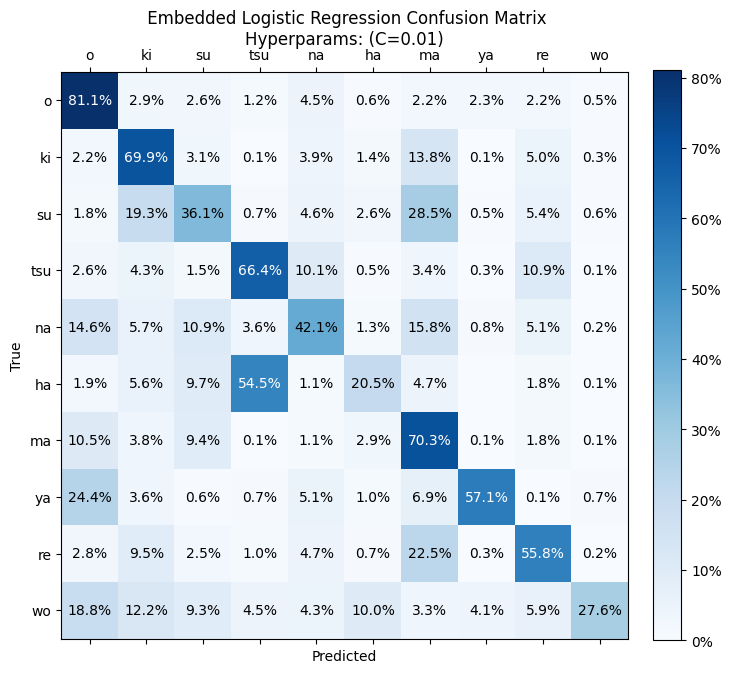

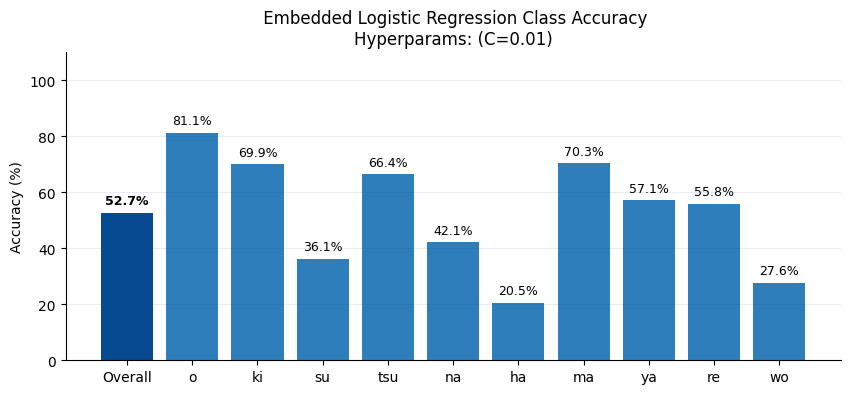

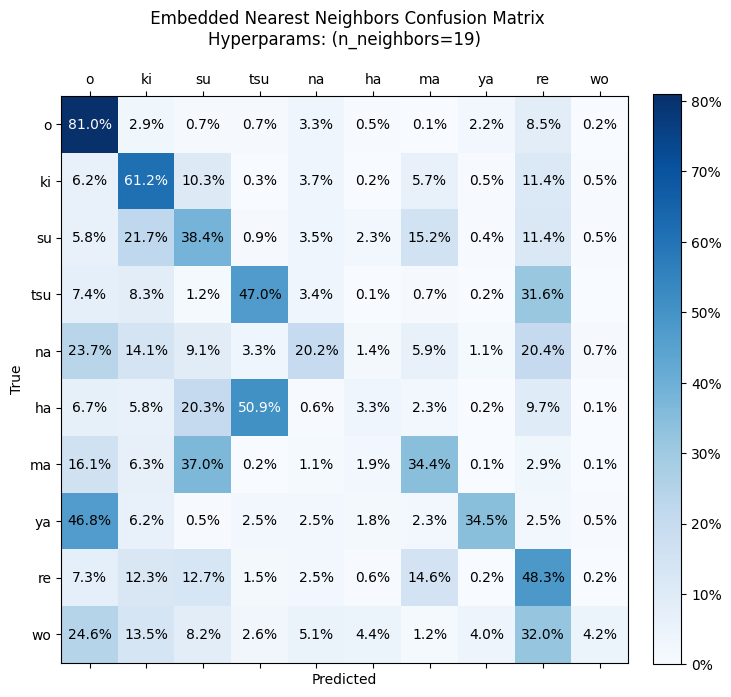

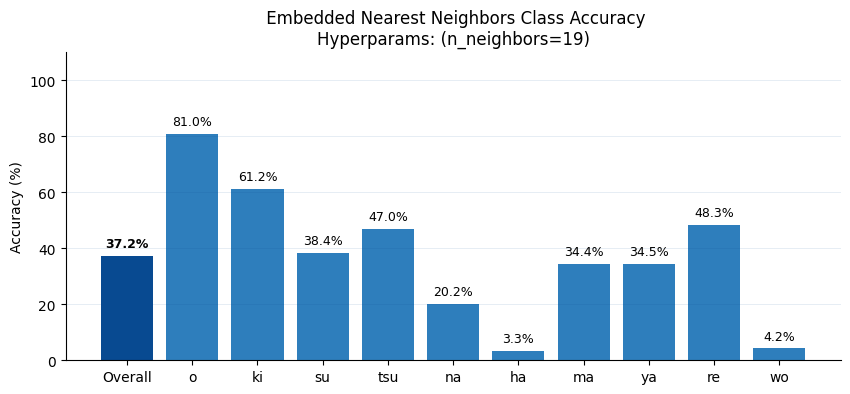

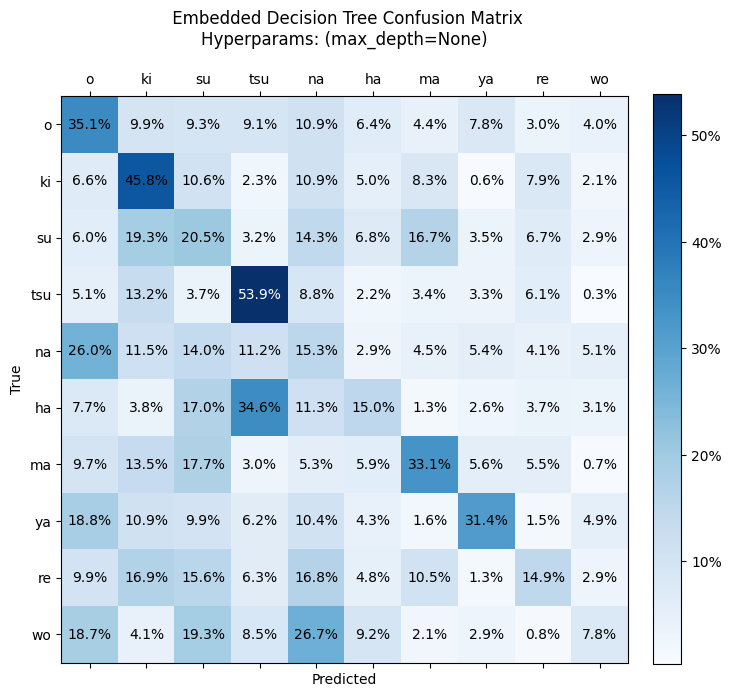

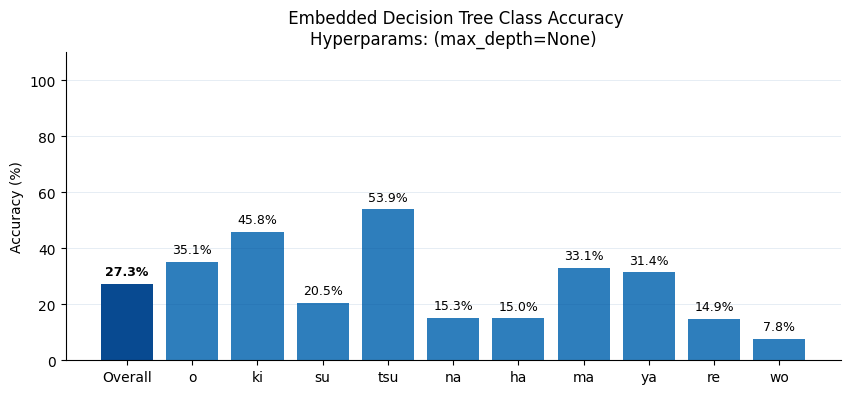

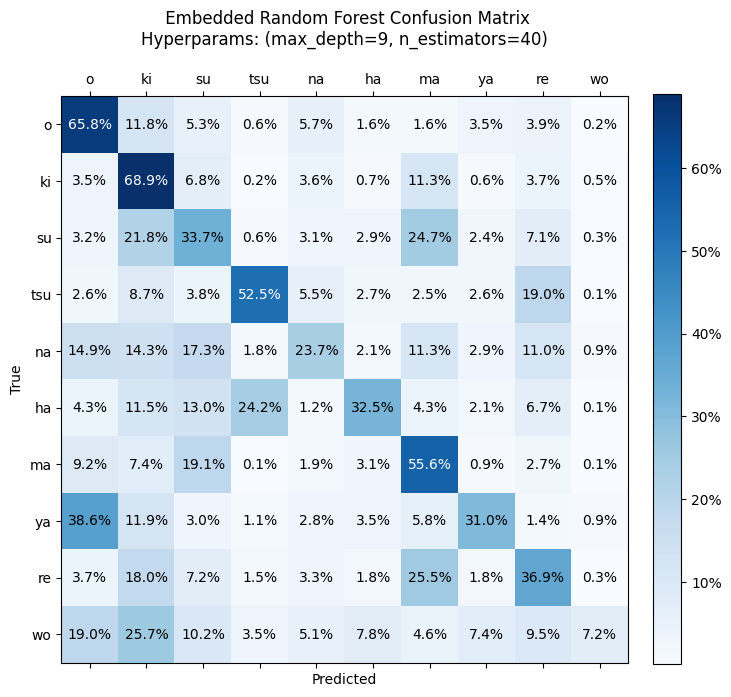

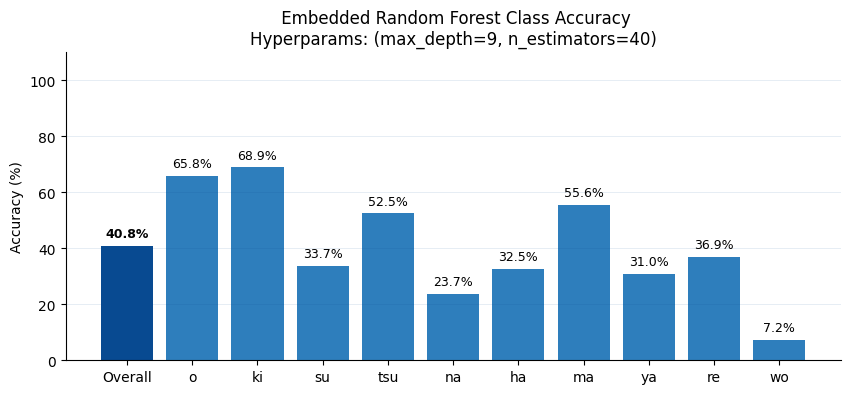

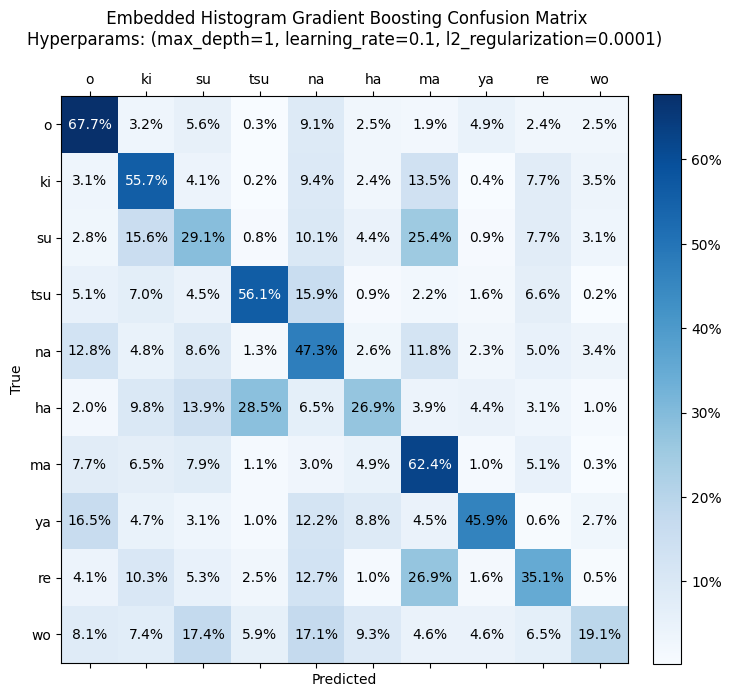

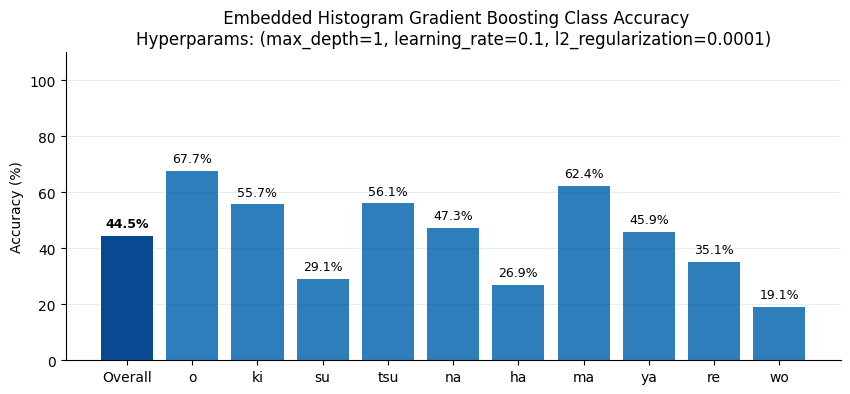

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step


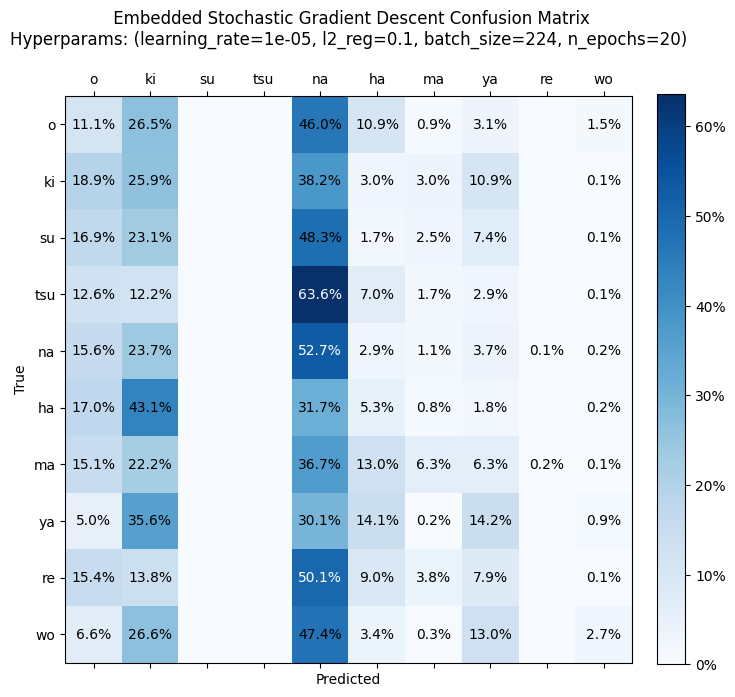

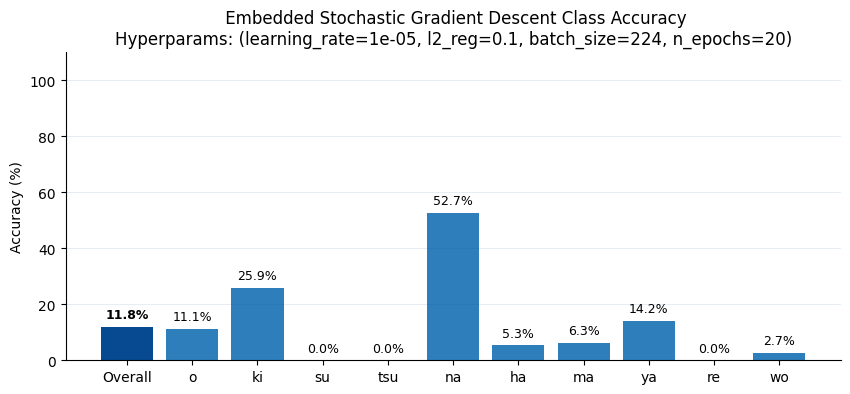

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step


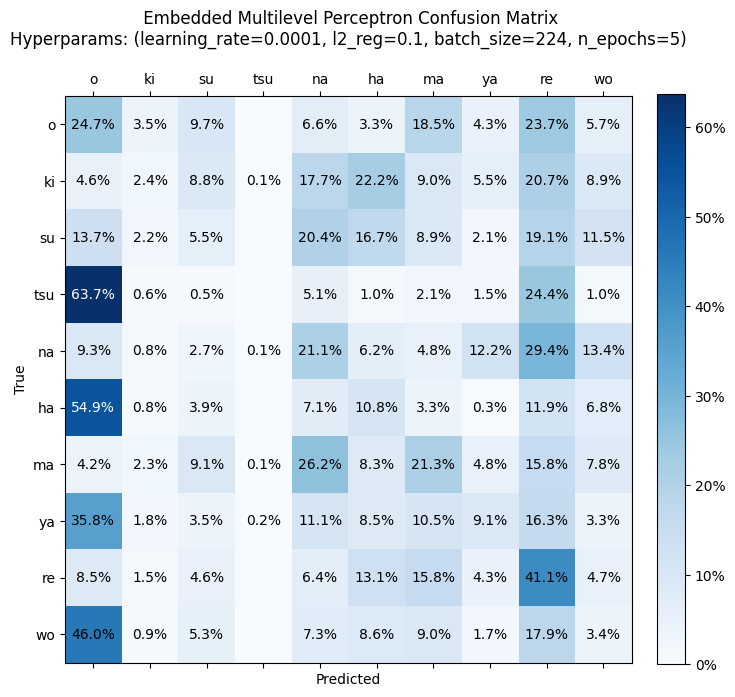

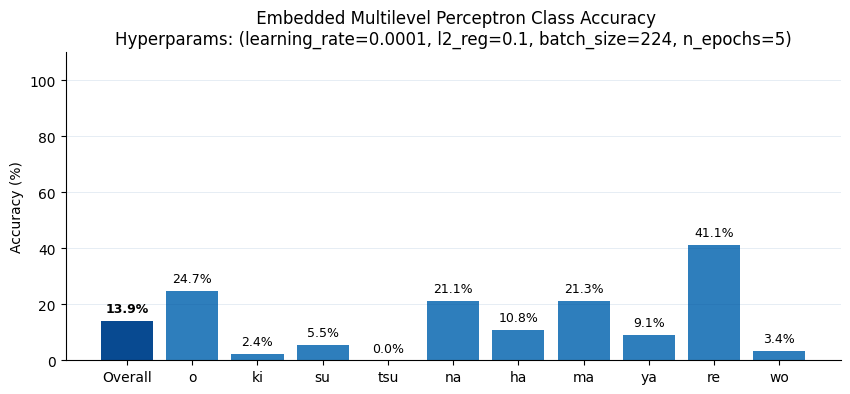

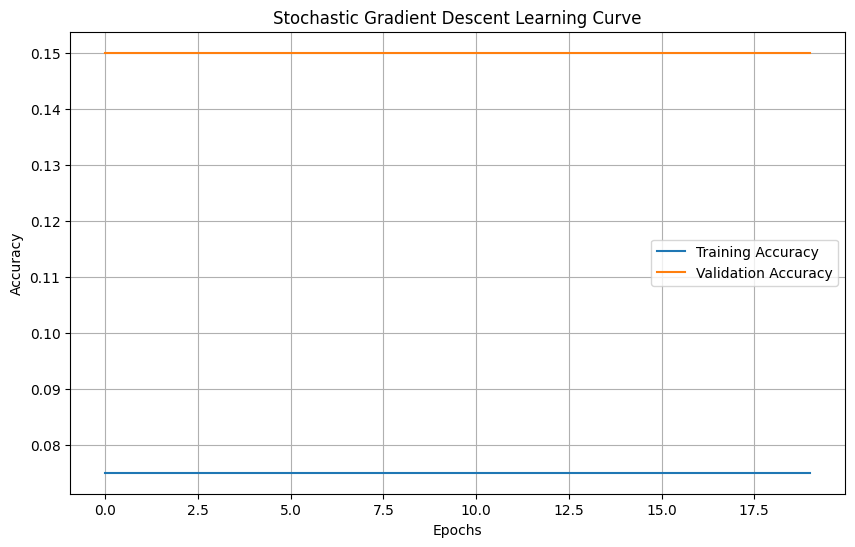

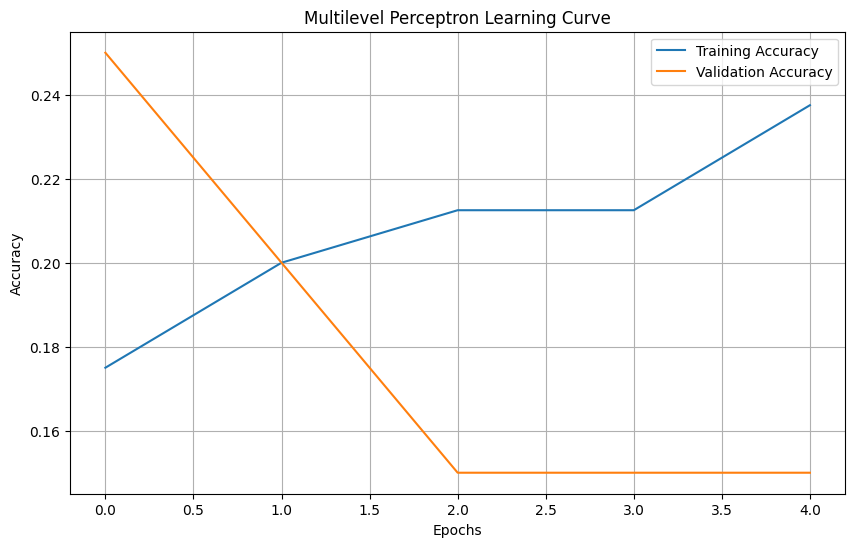

[I 2025-10-09 17:20:40,460] A new study created in memory with name: BayesSearch_Logistic Regression
[I 2025-10-09 17:20:40,468] Trial 0 finished with value: 0.3 and parameters: {'C': 0.001}. Best is trial 0 with value: 0.3.
[I 2025-10-09 17:20:40,512] A new study created in memory with name: BayesSearch_Nearest Neighbors
[I 2025-10-09 17:20:40,524] Trial 0 finished with value: 0.6 and parameters: {'n_neighbors': 7}. Best is trial 0 with value: 0.6.


Running 1 trials per model type with 80-20 train-validation split

=== Optimizing Logistic Regression ===
Best parameter values: {'C': 0.001}
Best validation accuracy = 30.000%
Evaluation accuracy = 20.183%

=== Optimizing Nearest Neighbors ===


[I 2025-10-09 17:20:40,895] A new study created in memory with name: BayesSearch_Decision Tree
[I 2025-10-09 17:20:40,917] Trial 0 finished with value: 0.15 and parameters: {'max_depth': 17}. Best is trial 0 with value: 0.15.
[I 2025-10-09 17:20:40,950] A new study created in memory with name: BayesSearch_Random Forest
[I 2025-10-09 17:20:41,010] Trial 0 finished with value: 0.35 and parameters: {'max_depth': 1, 'n_estimators': 80}. Best is trial 0 with value: 0.35.


Best parameter values: {'n_neighbors': 7}
Best validation accuracy = 60.000%
Evaluation accuracy = 43.651%

=== Optimizing Decision Tree ===
Best parameter values: {'max_depth': 17}
Best validation accuracy = 15.000%
Evaluation accuracy = 31.777%

=== Optimizing Random Forest ===


[I 2025-10-09 17:20:41,143] A new study created in memory with name: BayesSearch_Histogram Gradient Boosting


...

Best parameter values: {'max_depth': 16, 'learning_rate': 0.001, 'l2_regularization': 1e-05}
Best validation accuracy = 25.000%
Evaluation accuracy = 16.514%

=== Optimizing Stochastic Gradient Descent ===
{'input_shape': (784,), 'n_classes': 10, 'learning_rate': 1e-05, 'l2_reg': 0.1}


[I 2025-10-09 17:20:44,065] Trial 0 finished with value: 0.0 and parameters: {'learning_rate': 1e-05, 'l2_reg': 0.1, 'batch_size': 224, 'n_epochs': 5}. Best is trial 0 with value: 0.0.
[I 2025-10-09 17:20:44,408] A new study created in memory with name: BayesSearch_Multilevel Perceptron


Best parameter values: {'learning_rate': 1e-05, 'l2_reg': 0.1, 'batch_size': 224, 'n_epochs': 5}
Best validation accuracy = 0.000%
Evaluation accuracy = 5.821%

=== Optimizing Multilevel Perceptron ===
{'input_shape': (784,), 'n_classes': 10, 'learning_rate': 0.0001, 'l2_reg': 0.001}


[I 2025-10-09 17:20:45,019] Trial 0 finished with value: 0.10000000149011612 and parameters: {'learning_rate': 0.0001, 'l2_reg': 0.001, 'batch_size': 96, 'n_epochs': 5}. Best is trial 0 with value: 0.10000000149011612.
[I 2025-10-09 17:20:45,401] A new study created in memory with name: BayesSearch_Convolutional Neural Network
[I 2025-10-09 17:20:45,426] Trial 0 pruned. 


Best parameter values: {'learning_rate': 0.0001, 'l2_reg': 0.001, 'batch_size': 96, 'n_epochs': 5}
Best validation accuracy = 10.000%
Evaluation accuracy = 13.557%

=== Optimizing Convolutional Neural Network ===
{'input_shape': (28, 28, 1), 'n_classes': 10, 'learning_rate': 0.1, 'l2_reg': 1.0}
Error training Convolutional Neural Network: Exception encountered when calling Sequential.call().

Invalid input shape for input Tensor("Cast:0", shape=(None, 784), dtype=float32). Expected shape (None, 28, 28, 1), but input has incompatible shape (None, 784)

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 784), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>
No successful trials for Convolutional Neural Network, skipping.

Overall best model type: KNeighborsClassifier
Best params: {'n_neighbors': 7}
Best evaluation accuracy: 43.651%


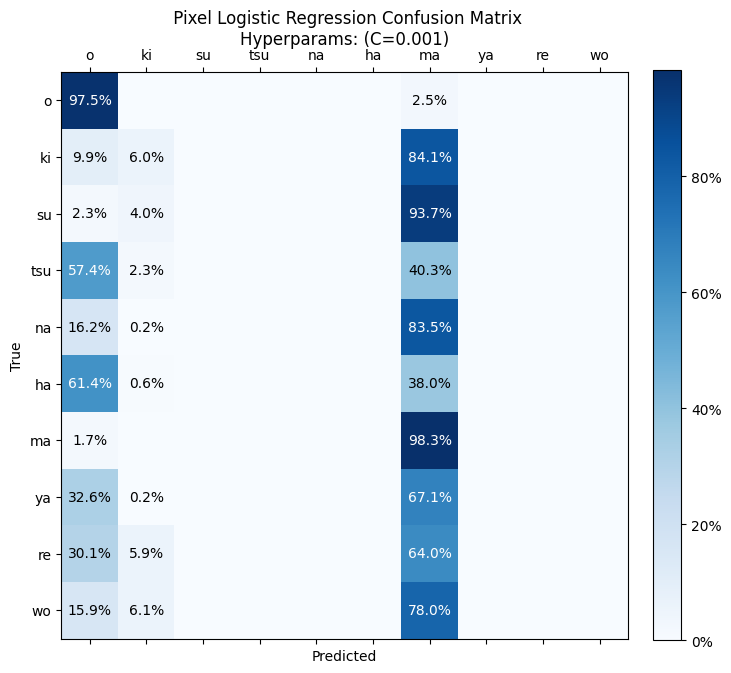

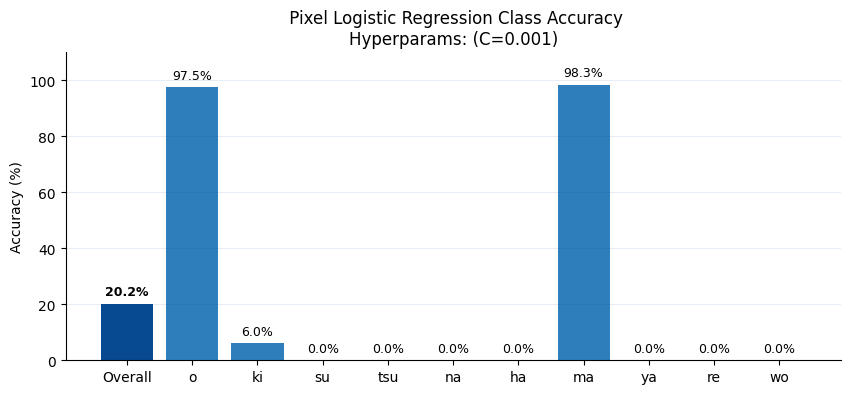

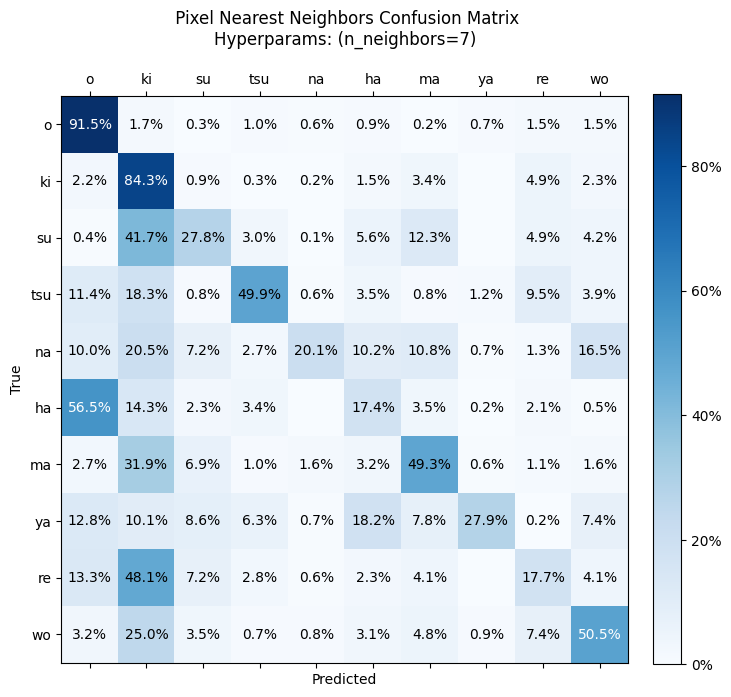

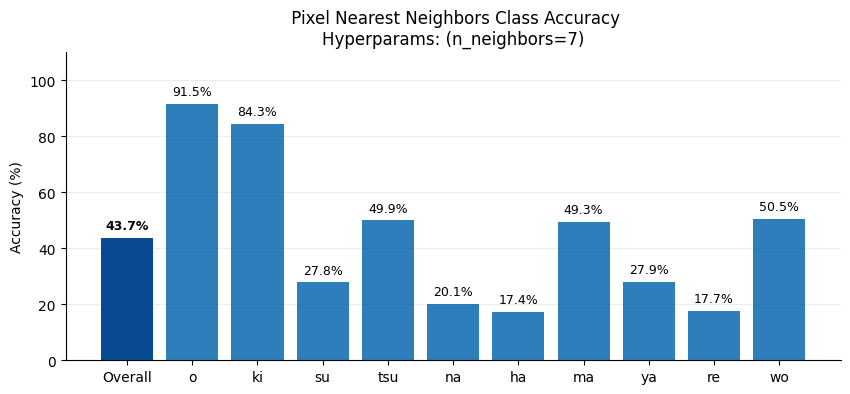

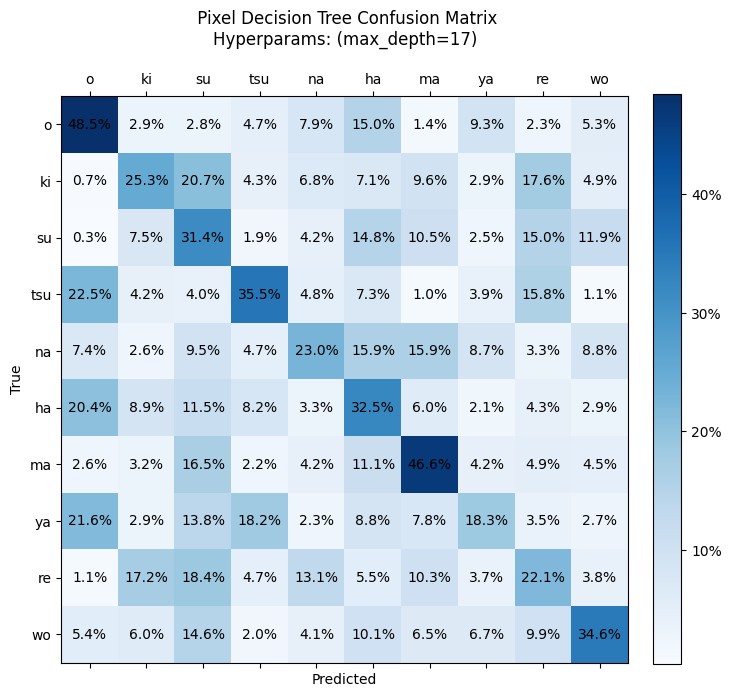

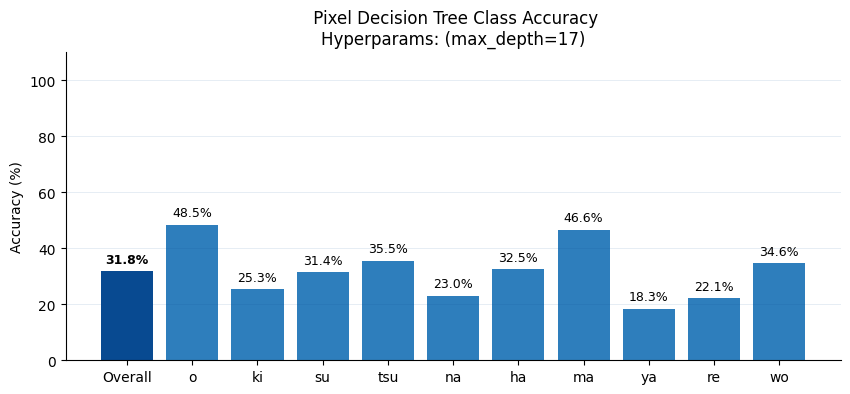

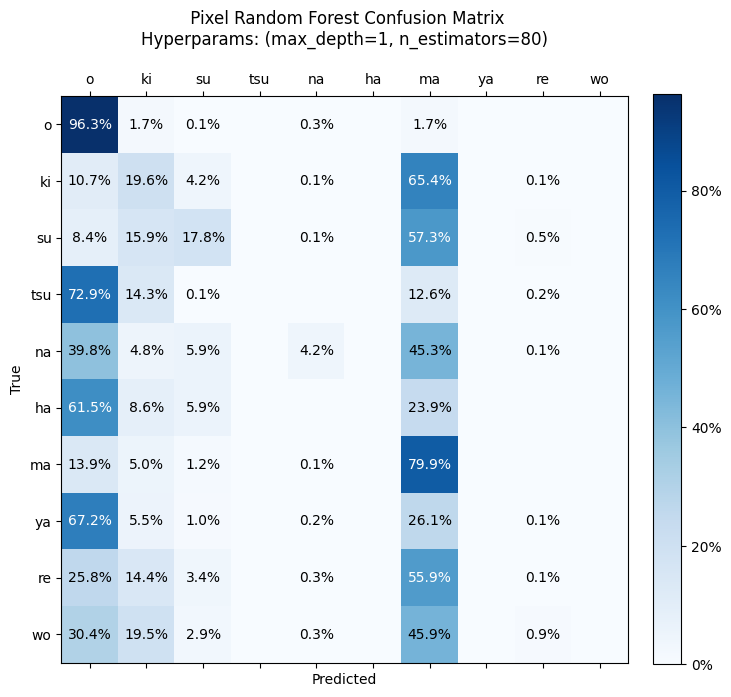

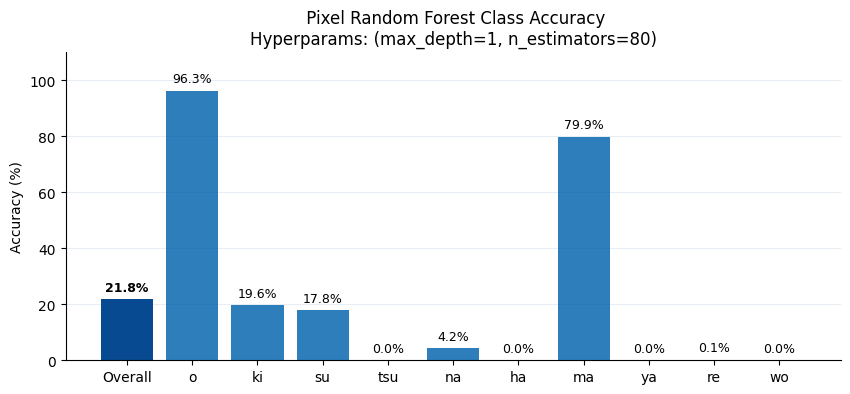

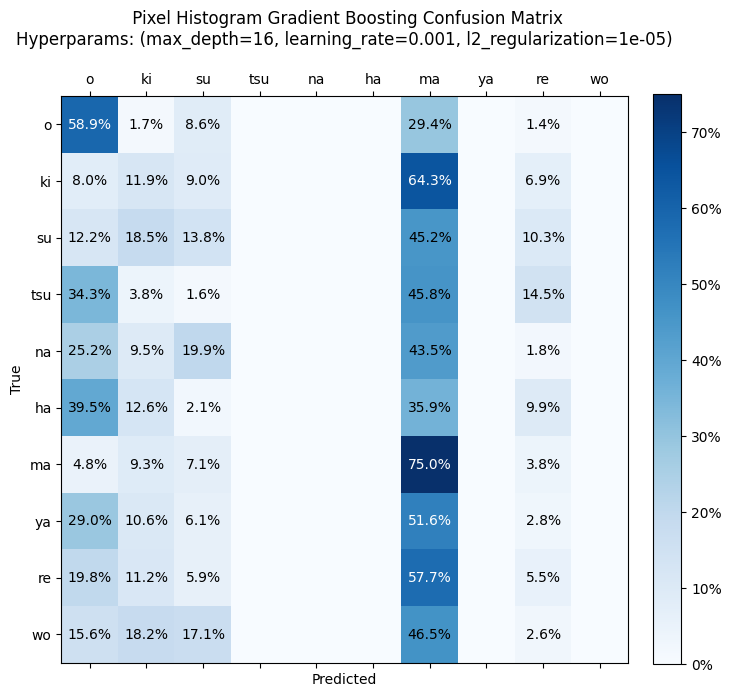

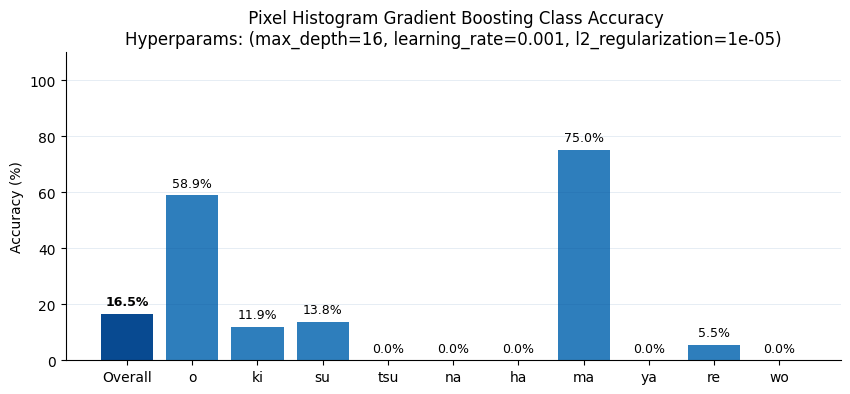

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step


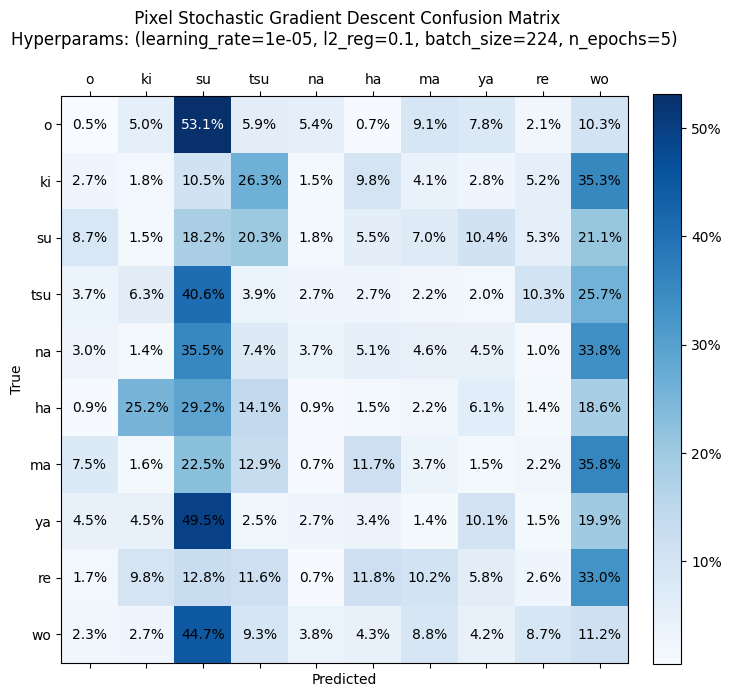

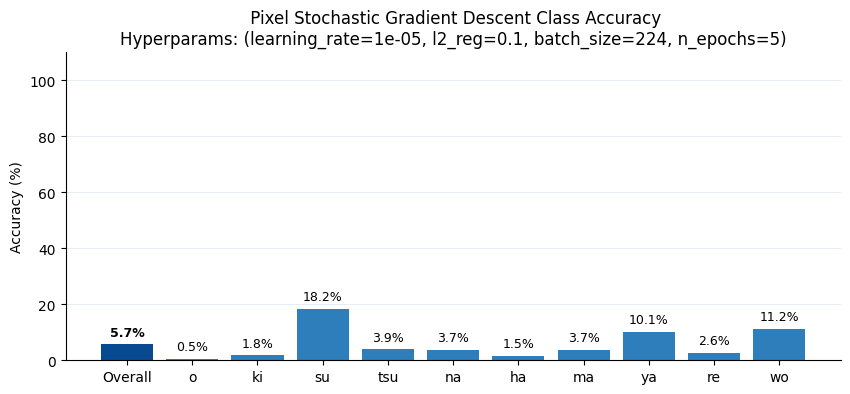

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step


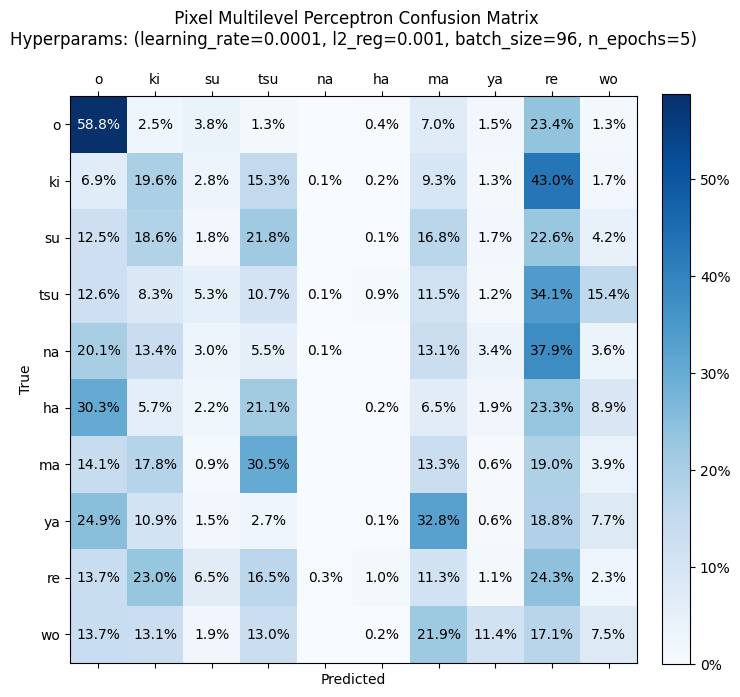

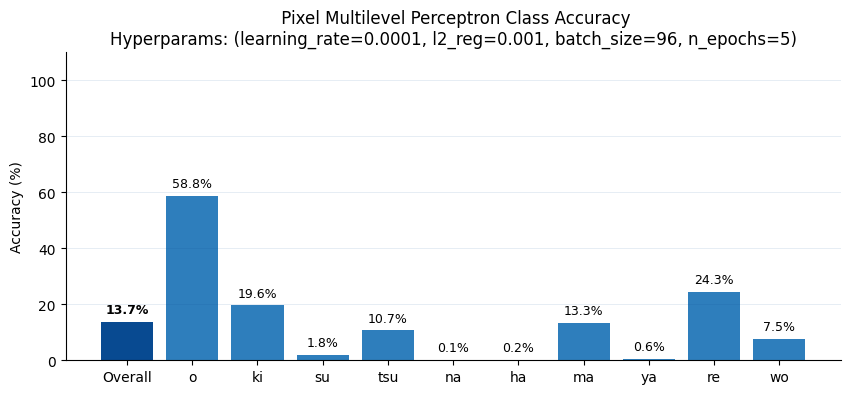

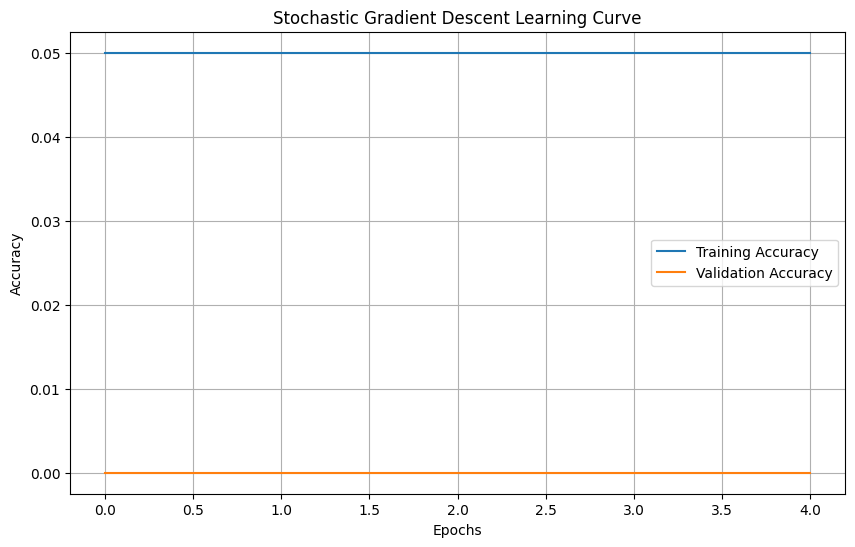

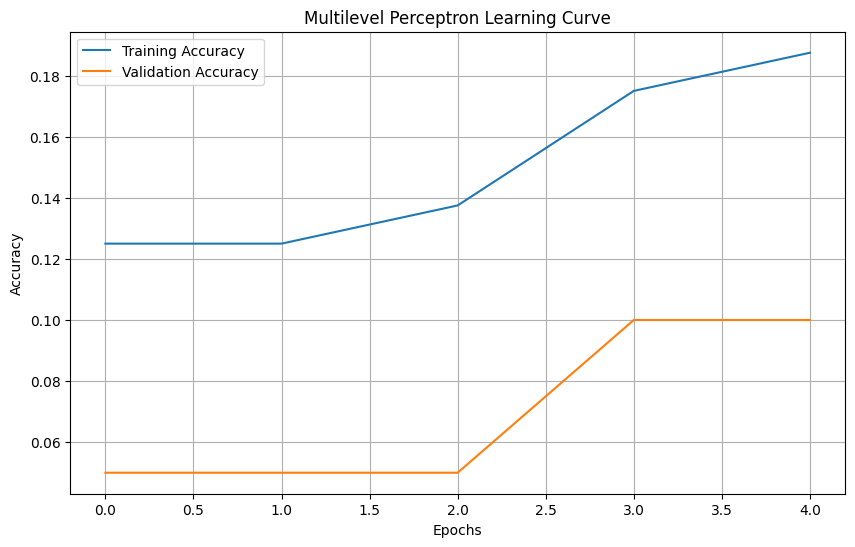

In [144]:
# ==============================
# Determine best model and parameters
# ==============================

# For embedding input, exclude CNN
model_classes_no_cnn = {k: v for k, v in model_classes.items() if k != "Convolutional Neural Network"}
model_param_map_no_cnn = {k: v for k, v in model_param_map.items() if k != "Convolutional Neural Network"}
dataset_size = 100  # Use a subset for quicker trials, use None for full dataset
trial_count = 1
val_ratio = 0.2

bgs_embed = BayesianGridSearch(
    X_embed[:dataset_size], y_enc[:dataset_size],
    model_classes_no_cnn, model_param_map_no_cnn, param_grid,
    n_trials=trial_count, val_size=val_ratio, random_state=0,
    X_eval=X_eval_embed, y_eval=y_eval_enc
)
best_model, best_params, best_val_acc = bgs_embed.run()
bgs_embed.plot_predictions(X_eval_embed, y_eval_enc, class_names=Kuzushiji_labels)
bgs_embed.plot_histories()

# For pixel input, include CNN
bgs_pixel = BayesianGridSearch(
    X_np[:dataset_size], y_enc[:dataset_size],
    model_classes, model_param_map, param_grid,
    n_trials=trial_count, val_size=val_ratio, random_state=0,
    X_eval=X_eval_np, y_eval=y_eval_enc
)
best_model_pixel, best_params_pixel, best_val_acc_pixel = bgs_pixel.run()
bgs_pixel.plot_predictions(X_eval_np, y_eval_enc, class_names=Kuzushiji_labels)
bgs_pixel.plot_histories()